Step 2: ML

In [1]:
import joblib
import pandas as pd
import os

# Load ML-ready data
# X
features_directory = "../data"
features_filename = "dp_magpie_features.pkl"
features_path = os.path.join(features_directory, features_filename)

X = joblib.load(features_path)

# y
targets_directory = "../data"
targets_filename = "dp_bandgap_targets.pkl"
targets_path= os.path.join(targets_directory, targets_filename)

y = joblib.load(targets_path)

print("Feature matrix shape:", X.shape)
print("Target vector length:", len(y))


Feature matrix shape: (574, 134)
Target vector length: 574


In [2]:
# Drop non-feature / non-numeric columns
non_feature_cols = [
    "material_id",
    "formula_pretty",
    "structure",
    "composition",
    "band_gap",
    "fields_not_requested",
    "energy_above_hull"
]

X_numeric = X.drop(columns=[c for c in non_feature_cols if c in X.columns])

print("Numeric features shape:", X_numeric.shape)

pd.DataFrame(X_numeric).head()


Numeric features shape: (574, 132)


,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,8.0,56.0,48.0,22.6,17.52,8.0,9.0,87.0,78.0,63.9,...,0.00031,0.000031,0.000056,0.0,12.0,229.0,217.0,97.6,102.72,12.0
1,8.0,40.0,32.0,18.7,12.84,8.0,8.0,87.0,79.0,62.8,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,94.5,99.00,12.0
2,8.0,41.0,33.0,19.0,13.20,8.0,8.0,87.0,79.0,63.7,...,0.00031,0.000031,0.000056,0.0,12.0,229.0,217.0,96.8,101.76,12.0
3,8.0,73.0,65.0,25.8,21.52,8.0,9.0,87.0,78.0,64.0,...,0.00031,0.000031,0.000056,0.0,12.0,229.0,217.0,97.6,102.72,12.0
4,8.0,83.0,75.0,17.8,14.08,8.0,46.0,87.0,41.0,79.0,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,70.1,81.34,12.0


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    random_state=42
)


print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 459
Test samples: 115


In [4]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest training completed!")


Random Forest training completed!


Mean Absolute Error (MAE): 0.399 eV
R² score: 0.755


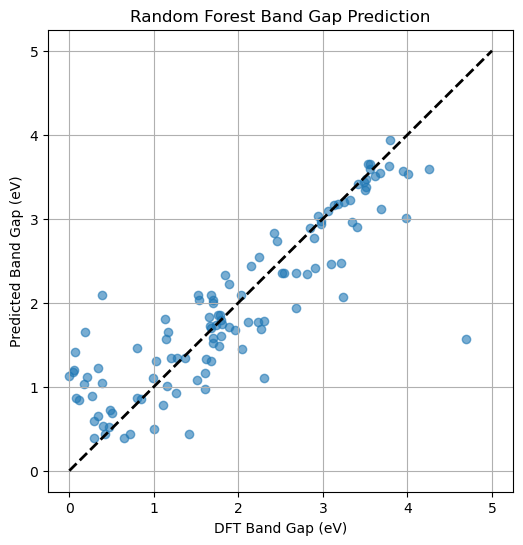

In [5]:
# Evaluate model performance
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Predict on test set
y_pred = rf.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f} eV")
print(f"R² score: {r2:.3f}")

# Optional: scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0,5],[0,5], "k--", lw=2)
plt.xlabel("DFT Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Random Forest Band Gap Prediction")
plt.grid(True)
plt.show()


In [6]:
# Feature importance
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 10 features
for i in range(10):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.4f}")


MagpieData maximum Column: 0.1147
MagpieData range Column: 0.0589
MagpieData maximum SpaceGroupNumber: 0.0567
MagpieData minimum NValence: 0.0408
MagpieData range Electronegativity: 0.0372
MagpieData range NdValence: 0.0355
MagpieData range GSmagmom: 0.0352
MagpieData maximum MeltingT: 0.0300
MagpieData range NValence: 0.0284
MagpieData maximum MendeleevNumber: 0.0257


In [9]:
import joblib

# Suppose X is your feature matrix from Step 2 (after featurization)
# Save feature column names to a file
FEATURE_COLUMNS = X_numeric.columns.tolist()
joblib.dump(FEATURE_COLUMNS, "feature_columns.pkl")

print(f"Saved {len(FEATURE_COLUMNS)} feature columns to 'feature_columns.pkl'")


Saved 132 feature columns to 'feature_columns.pkl'


In [8]:
# Save model for GA
joblib.dump(rf, "rf_bandgap_dp.pkl")
print("Random Forest model saved as rf_bandgap_dp.pkl")


Random Forest model saved as rf_bandgap_dp.pkl
